In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Persiapan Environment & Instalasi

In [2]:
# Instalasi library Ultralytics
!pip install ultralytics -q

import os
from ultralytics import YOLO
from IPython.display import display, Image
import matplotlib.pyplot as plt

# Cek apakah GPU tersedia (sangat disarankan untuk training)
import torch
print(f"Menggunakan perangkat: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Menggunakan perangkat: Tesla T4


In [3]:
import pandas as pd
import os

# Tentukan lokasi folder
path_folder = '/content/drive/MyDrive/IndoorFireSmoke'

# Cek daftar file di dalamnya
print(os.listdir(path_folder))

# df = pd.read_csv(f'{path_folder}/metadata.csv')

['Indoor Fire Smoke_Kelompok 2.zip', 'Indoor_Fire_Smoke', 'metadata.csv', 'Indoor_Fire_Smoke1', 'Indoor_Fire_Smoke2']


# 2. Data Understanding: Struktur Dataset YOLO

## Dataset Deteksi Api dan Asap Dalam Ruangan (Indoor Fire Smoke)

Dataset ini berisi **5.000 gambar** lingkungan dalam ruangan (*indoor*) yang telah diberi label objek untuk keperluan deteksi api dan asap. Setiap gambar dilengkapi dengan anotasi *bounding box* untuk mendeteksi api dan asap yang terlihat di berbagai skenario dalam ruangan, seperti rumah, kantor, dan gedung bangunan.

Semua gambar merupakan gambar nyata yang ditangkap dengan kondisi pencahayaan dan lingkungan dalam ruangan yang bervariasi. Dataset ini sangat cocok digunakan untuk mendukung pengembangan model *object detection* (seperti YOLO) pada sistem keamanan dan pemantauan pintar.

## Detail Pembagian Dataset

Dataset ini telah dibagi menjadi tiga bagian dengan proporsi **70-15-15** agar siap digunakan untuk proses *machine learning*:

* **Training Set (70%):** 3.500 gambar
* **Validation Set (15%):** 750 gambar
* **Testing Set (15%):** 750 gambar

# 3. Model Training Execution

Menjalankan Training YOLOv8

In [7]:
import torch

# Definisikan ulang variabel device
device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Menggunakan device: {device}") # Seharusnya muncul '0' karena pakai T4 GPU

# Baru panggil trainingnya
results = model.train(
    data='/content/drive/MyDrive/IndoorFireSmoke/Indoor_Fire_Smoke2/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolov8_indoor_fire',
    device=device  # Sekarang 'device' sudah ada isinya
)

Menggunakan device: 0
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/IndoorFireSmoke/Indoor_Fire_Smoke2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_indoor_fire, nbs=64, nms=False, opset=

# 4. Save Model & Evaluasi

Menyimpan Model (Exporting)

In [13]:
import shutil

# Path model terbaik hasil training
source_path = '/content/runs/detect/yolov8_indoor_fire/weights/best.pt'
# Path tujuan di Google Drive kamu
destination_path = '/content/drive/MyDrive/IndoorFireSmoke/yolov8_indoor_fire_best.pt'

try:
    shutil.copy(source_path, destination_path)
    print(f"Model berhasil disimpan di: {destination_path}")
except FileNotFoundError:
    print("File model tidak ditemukan. Pastikan training sudah selesai dengan benar.")

Model berhasil disimpan di: /content/drive/MyDrive/IndoorFireSmoke/yolov8_indoor_fire_best.pt


Evaluasi Model pada Validation Set

In [9]:
# 1. Load model yang sudah dilatih (best weights)
model_trained = YOLO('/content/runs/detect/yolov8_indoor_fire/weights/best.pt')

# 2. Jalankan validasi
metrics = model_trained.val()

print("\n--- METRIK EVALUASI ---")
print(f"mAP 50-95: {metrics.box.map:.3f}") # Rata-rata presisi keseluruhan
print(f"mAP 50: {metrics.box.map50:.3f}")    # Presisi pada threshold 0.5 (umum digunakan)
print(f"Precision: {metrics.box.mp:.3f}")   # Seberapa akurat tebakan model
print(f"Recall: {metrics.box.mr:.3f}")      # Seberapa banyak objek yang berhasil ditemukan

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 20.1±14.2 MB/s, size: 29.8 KB)
val: Scanning /content/drive/MyDrive/IndoorFireSmoke/Indoor_Fire_Smoke2/valid/labels.cache... 750 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 750/750 209.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 3.6it/s 13.0s
                   all        750       1043      0.876      0.805      0.868      0.549
                  Fire        397        547      0.866      0.827      0.873      0.532
                 Smoke        431        496      0.886      0.782      0.864      0.567
Speed: 1.6ms preprocess, 4.2ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val

--- METRIK EVALUASI ---
mAP 50-95: 0.549
mAP 50: 0.868
Precisi

Visualisasi Hasil Training

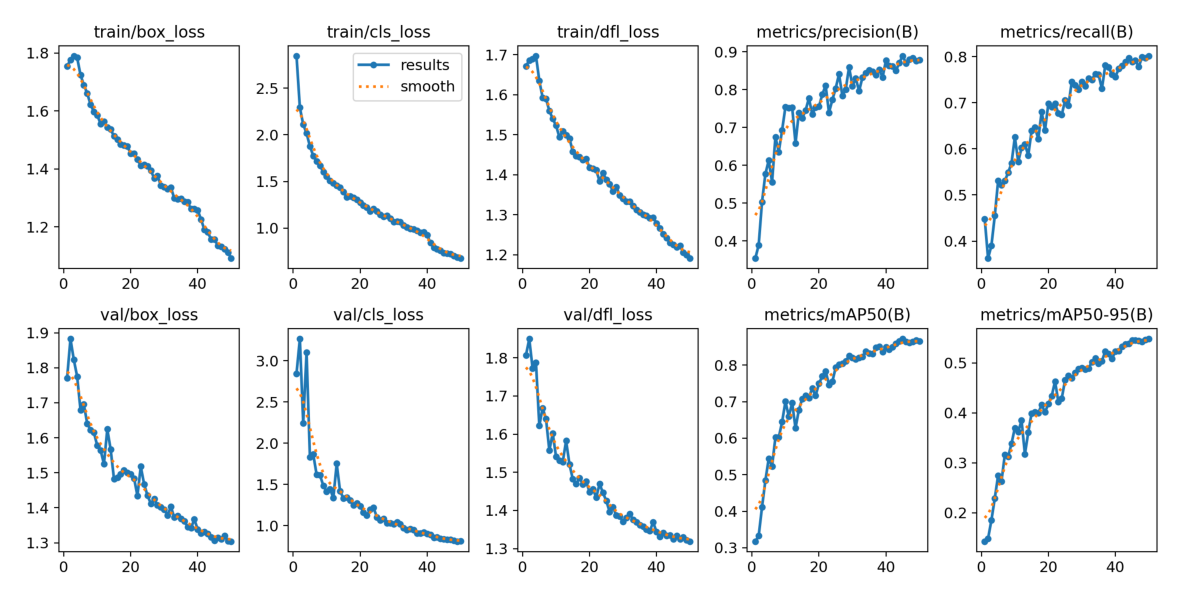

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Menampilkan grafik hasil (Loss, mAP, dll)
results_img_path = '/content/runs/detect/yolov8_indoor_fire/results.png'

if os.path.exists(results_img_path):
    img = mpimg.imread(results_img_path)
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print("Grafik hasil tidak ditemukan.")